### Week 8 — Sentiment Analysis
1. Task:
   - Use a reviews dataset.

2. Steps:
   - Preprocess text
   - Train sentiment model
   - Predict sentiment for new reviews

3. Example predictions:

    - "Product is amazing" → Positive

    - "Worst experience" → Negative

### importing Libraries

In [1]:
import re
import string

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

pd.set_option("display.max_colwidth", 100)
print("Libraries imported successfully.")

Libraries imported successfully.


### Load Dataset

In [2]:
df = pd.read_csv('Customer_Sentiment.csv')
print('Shape:',df.shape)
df.head()

Shape: (26880, 13)


,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
0,1,male,60+,north,automobile,online,flipkart,1,very disappointed with the quality.,negative,46,yes,yes
1,2,other,46-60,central,books,online,swiggy instamart,5,fast delivery and great packaging.,positive,5,yes,no
2,3,female,36-45,east,sports,online,facebook marketplace,1,very disappointed with the quality.,negative,38,yes,yes
3,4,female,18-25,central,groceries,online,zepto,2,product stopped working after few days.,negative,16,yes,yes
4,5,female,18-25,east,electronics,online,croma,3,neutral about the quality.,neutral,15,yes,no


In [4]:
# we only need the review text and sentiment label.
data = df[['customer_id','review_text','sentiment']].dropna().copy()
print(data['sentiment'].value_counts())
data.head()

sentiment
negative    10777
positive    10698
neutral      5405
Name: count, dtype: int64


,customer_id,review_text,sentiment
0,1,very disappointed with the quality.,negative
1,2,fast delivery and great packaging.,positive
2,3,very disappointed with the quality.,negative
3,4,product stopped working after few days.,negative
4,5,neutral about the quality.,neutral


### Visualization for customer review 

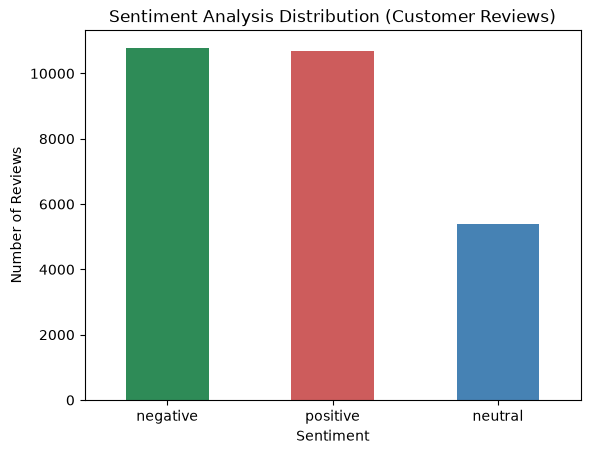

In [5]:
data['sentiment'].value_counts().plot(kind='bar',color=['seagreen','indianred','steelblue'])
plt.title('Sentiment Analysis Distribution (Customer Reviews)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

### Text Preprocessing

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def text_preprocess(review):
    review = str(review).lower()
    review = re.sub(r'[^a-zA-Z]',' ',review)
    token = review.split()
    token = [
        lemmatizer.lemmatize(t,pos='v')
        for t in token if t not in stop_words
    ]
    return ' '.join(token)

data['cleaned_review'] = data['review_text'].apply(text_preprocess)
data[['review_text','cleaned_review','sentiment']].head(10)
    

,review_text,cleaned_review,sentiment
0,very disappointed with the quality.,disappoint quality,negative
1,fast delivery and great packaging.,fast delivery great package,positive
2,very disappointed with the quality.,disappoint quality,negative
3,product stopped working after few days.,product stop work days,negative
4,neutral about the quality.,neutral quality,neutral
5,"amazing experience, highly recommend!",amaze experience highly recommend,positive
6,great value for money.,great value money,positive
7,excellent product! exceeded expectations.,excellent product exceed expectations,positive
8,"product is okay, nothing special.",product okay nothing special,neutral
9,great value for money.,great value money,positive


### Train/Test Split

In [11]:
X = data['cleaned_review']
y =data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42, stratify=y)

print('Train Size:',X_train.shape[0])
print('Test Size:',X_test.shape[0])

Train Size: 18816
Test Size: 8064
